In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import BatchNorm2d, Conv2d, MaxPool2d, Module, ReLU
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import json

from sklearn.model_selection import train_test_split
from dataclasses import dataclass, field
from torch.utils.data import DataLoader
from typing import Callable, List, Dict, Tuple, Optional, Set
from torch.utils import data
from torch.utils.data import Dataset
from torchvision.transforms import ToTensor
from PIL import Image

plt.style.use('dark_background') 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de entrenamiento: {device}")
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

Dispositivo de entrenamiento: cuda
GPU detectada: Tesla P100-PCIE-16GB


In [2]:
#Tokenizer
def _str_to_charlist(text: str) -> List[str]:
    return [char for char in text]


def _generate_bag_of_chars(src: Tuple[str] | List[str]) -> Set[str]:
    return {i for i in src}


def _tokenize_data_list(data: List[str]):
    chars = [_generate_bag_of_chars(_str_to_charlist(word)) for word in data]

    out_bag = set([])

    for bag in chars:
        out_bag.update(bag)

    return out_bag


def save_tokens_to_file(
    data: List[str], file_name: str = "tokens.json", out_dir: Optional[str] = None
) -> None:
    out_file = file_name

    if out_dir is not None:
        if not os.path.exists(out_dir):
            os.makedirs(out_dir, exist_ok=True)
            out_file = os.path.join(out_dir, file_name)
        else:
            out_file = os.path.join(out_dir, file_name)

    tokens = _tokenize_data_list(data)

    tokens_dict = {tok: (num + 1) for num, tok in enumerate(tokens)}
    tokens_dict["<Blank>"] = 0

    with open(out_file, "w", encoding="utf-8") as file:
        json.dump(
            tokens_dict,
            file,
            sort_keys=True,
            indent=4,
            separators=(",", ": "),
            ensure_ascii=False,
        )


class Tokenizer:
    def __init__(self, src: str) -> None:
        if not os.path.exists(src):
            raise FileNotFoundError(f"File {src} no found")

        self.file = src

        with open(src, "r", encoding="utf-8") as file:
            self._encode = json.load(file)

        self._decode = {v: k for k, v in self._encode.items()}

        self._ntokens = max(list(self._encode.values()))

    @property
    def ntokens(self):
        return self._ntokens + 1  # Sum the empty char (<Blank>)

    def encoding(self, text: str | List[str]) -> Tuple[np.ndarray, np.ndarray]:
        if not isinstance(text, list):
            input_text = _str_to_charlist(str(text).lower())
            out_array = np.array([self._encode[char] for char in input_text])
            lengths = [len(input_text)]
            return out_array, np.array(lengths)

        else:
            input_text = [_str_to_charlist(word.lower()) for word in text]
            lengths = np.array([len(word) for word in input_text], dtype=np.int64)

            max_word_size = lengths.max()
            out_array = np.zeros(shape=(len(input_text), max_word_size), dtype=np.int64)

            for sample, word in enumerate(input_text):
                for idx, char in enumerate(word):
                    out_array[sample, idx] = self._encode[char]

            return out_array, lengths

    def decoding(self, matrix: np.ndarray) -> np.ndarray:
        if matrix.ndim == 2:
            nrows = matrix.shape[0]
            result = np.empty(shape=(nrows,), dtype=object)
            for row in range(nrows):
                chars = [self._decode[code] for code in matrix[row]]
                result[row] = "".join(chars).replace("<Blank>", "")

            return result
        else:
            chars = [self._decode[code] for code in matrix]
            result = np.array(["".join(chars).replace("<Blank>", "")], dtype=object)
            return result


In [3]:
# Datasets
@dataclass
class Datadict:
    data: Dict[str, str] = field(default_factory=dict)
    index: List[str] = field(default_factory=list)


def _json_to_dict(path: str) -> Dict[str, str]:
    with open(path, "r", encoding="utf-8") as f_in:
        return json.load(f_in)


def load_data(path: str) -> Datadict:
    safe_path = os.path.join(".", path)

    if not os.path.exists(safe_path):
        raise FileNotFoundError(f"Not such file or directory found: {path}")

    temp_data = _json_to_dict(safe_path)
    temp_idx = list(temp_data.keys())

    return Datadict(data=temp_data, index=temp_idx)


class HandwrittenData(Dataset):
    def __init__(
        self,
        datadict: Datadict,
        data_path: str,
        transform: Optional[Callable] = None,
    ) -> None:
        if not os.path.exists(data_path):
            raise FileNotFoundError(f"Not file o dir found: {data_path}")

        super().__init__()
        self.datadict = datadict
        self.path = data_path
        self.transform = transform
        self.to_tensor = ToTensor()

        self.valid_index = []
        archivos_perdidos = 0

    def __len__(self) -> int:
        return len(self.datadict.index)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, str]:
        file_name = self.datadict.index[index]
        label = self.datadict.data.get(file_name, "")

        full_path = os.path.join(self.path, file_name)
        img = Image.open(full_path)

        if self.transform is not None:
            img = self.transform(img)

        if not isinstance(img, torch.Tensor):
            img = self.to_tensor(img)

        return img, label


class OCRcollateFn:
    def __init__(self, tokenizer: Tokenizer) -> None:
        self._tokenizer = tokenizer

    def __call__(
        self, batch: List[Tuple[torch.Tensor, str]]
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        features, labels = zip(*batch)

        feat_tensor = torch.stack(features)

        targets, targets_len = self._tokenizer.encoding(list(labels))

        targets_tensor = torch.from_numpy(targets)
        targets_len_tensor = torch.from_numpy(targets_len)

        return feat_tensor, targets_tensor, targets_len_tensor

In [4]:
def _resize_data(img: Image.Image):
    factor = 32 / img.height
    new_width = int(img.width * factor)

    safe_width = min(128, new_width)

    return img.resize((safe_width, 32))


def _add_padding(img: Image.Image):
    new_width = 128
    new_height = 32

    temp_img = Image.new(img.mode, (new_width, new_height), 255)

    temp_img.paste(img, (0, 0))

    return temp_img


def process_img(img: Image.Image):
    temp_out = _resize_data(img)

    if temp_out.height == 32 and temp_out.width == 128:
        return temp_out
    else:
        return _add_padding(temp_out)

In [5]:
# Model
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import BatchNorm2d, Conv2d, MaxPool2d, Module, ReLU


class CNN(Module):
    def __init__(self) -> None:
        super().__init__()

        self.cnn = nn.Sequential(
            # First Conv Layer -> reduce input by a half
            Conv2d(in_channels=1, out_channels=64, kernel_size=3, padding=1),
            ReLU(inplace=True),
            MaxPool2d(kernel_size=2, stride=2),
            # Second Conv Layer -> reduce input by a half
            Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            ReLU(inplace=True),
            MaxPool2d(kernel_size=2, stride=2),
            # Third Conv Layer -> Only extract features
            Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            BatchNorm2d(256),
            ReLU(inplace=True),
            # Fourth Conv Layer -> Asymmetric Pooling
            Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            ReLU(inplace=True),
            MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
            # Fifth Conv Layer -> More features extraction
            Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            BatchNorm2d(512),
            ReLU(inplace=True),
            # Sixth Conv Layer -> Last Asymmetric Pooling
            Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            ReLU(inplace=True),
            MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
            # Seventh Conv Layer -> To 1 pixel feat representation
            Conv2d(
                in_channels=512, out_channels=512, kernel_size=2, stride=1, padding=0
            ),
            ReLU(inplace=True),
        )

    def forward(self, x):
        return self.cnn(x)


class RNN_Encoder(nn.Module):
    def __init__(self, input_size=512, hidden_size=256):
        super().__init__()

        self.rnn = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.1,
        )

    def forward(self, x):
        x = x.squeeze(2)
        x = x.permute(0, 2, 1)
        x, *_ = self.rnn(x)
        return x


class HandwrittenCRNN(nn.Module):
    def __init__(self, num_classes: int, hidden_size: int = 256):
        super().__init__()

        self.vision = CNN()
        self.seq = RNN_Encoder(input_size=512, hidden_size=hidden_size)
        self.clf = nn.Linear(in_features=hidden_size * 2, out_features=num_classes)

    def forward(self, x):
        x = self.vision(x)
        x = self.seq(x)
        x = self.clf(x)

        return x

    def inference(self, x):
        logits = self.forward(x)

        probs = F.softmax(logits, dim=-1)

        return probs

In [6]:
tokens_dict = {
    "0": 40, "1": 18, "2": 36, "3": 25, "4": 30, "5": 21, "6": 29, "7": 2, "8": 10, "9": 17,
    "<Blank>": 0,
    "a": 41, "b": 32, "c": 20, "d": 13, "e": 35, "f": 28, "g": 3, "h": 14, "i": 39, "j": 7,
    "k": 22, "l": 42, "m": 12, "n": 38, "o": 33, "p": 31, "q": 1, "r": 37, "s": 43, "t": 11,
    "u": 26, "v": 27, "w": 16, "x": 24, "y": 4, "z": 19,
    "á": 15, "é": 6, "í": 9, "ñ": 34, "ó": 5, "ú": 8, "ü": 23
}

tokens_file = "/kaggle/working/tokens.json"
with open(tokens_file, "w", encoding="utf-8") as f:
    json.dump(tokens_dict, f, ensure_ascii=False, indent=4)

In [7]:
def load_data_raw(json_path: str) -> dict:
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)

def save_split(data_dict: dict, out_path: str):
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(data_dict, f, indent=4, ensure_ascii=False)

## Preparación de Datos (split)

In [8]:
base_path = os.path.join("/kaggle/input/datasets/verack/spanish-handwritten-characterswords",
                       "datos_entrenamiento_augmented",
                       "PERFECT_CUT_a_z_1_9_aug_SYNTHETIC")

data_dict_path = os.path.join(base_path, "0annotation.json")
data_dict_aug_path = os.path.join(base_path, "synthetic_annotation.json")

out_dir = "include" # Dónde se guardarán los splits
os.makedirs(out_dir, exist_ok=True)

print("Cargando y formateando diccionarios...")
raw_real = load_data_raw(data_dict_path)
raw_aug = load_data_raw(data_dict_aug_path)

dict_real_paths = {os.path.join(base_path, k): v for k, v in raw_real.items()}
dict_aug_paths = {os.path.join(base_path, k): v for k, v in raw_aug.items()}

real_items = list(dict_real_paths.items())

train_real, temp_split = train_test_split(real_items, test_size=0.20, random_state=42)
val_real, test_real = train_test_split(temp_split, test_size=0.50, random_state=42)

dict_train = dict(train_real)
dict_val = dict(val_real)
dict_test = dict(test_real)

print(f"Datos reales originales: {len(real_items)}")
print(f" -> Train real: {len(dict_train)}")
print(f" -> Val real:   {len(dict_val)}")
print(f" -> Test real:  {len(dict_test)}")


print(f"\nInyectando {len(dict_aug_paths)} imágenes sintéticas al Train set...")
dict_train.update(dict_aug_paths)
print(f" -> Train FINAL (Real + Sintético): {len(dict_train)}")


save_split(dict_train, os.path.join(out_dir, "train_split.json"))
save_split(dict_val, os.path.join(out_dir, "val_split.json"))
save_split(dict_test, os.path.join(out_dir, "test_split.json"))

print(f"\n¡Splits generados con éxito en la carpeta '{out_dir}'!")

Cargando y formateando diccionarios...
Datos reales originales: 172229
 -> Train real: 137783
 -> Val real:   17223
 -> Test real:  17223

Inyectando 79545 imágenes sintéticas al Train set...
 -> Train FINAL (Real + Sintético): 153855

¡Splits generados con éxito en la carpeta 'include'!


In [9]:
def load_valid_chars(tokens_path: str) -> set:
    """Carga el archivo de tokens y devuelve un set con los caracteres válidos."""
    with open(tokens_path, "r", encoding="utf-8") as f:
        tokens = json.load(f)

    valid_chars = set(tokens.keys())

    if "<Blank>" in valid_chars:
        valid_chars.remove("<Blank>")

    return valid_chars


def check_json_vocab(json_path: str, valid_chars: set) -> None:
    """Escanea los valores de un JSON buscando caracteres no permitidos."""
    print(f"Loking  for..: {os.path.basename(json_path)}...")

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    all_text = "".join(data.values()).lower()

    found_chars = set(all_text)

    invalid_chars = found_chars - valid_chars

    if not invalid_chars:
        print("Not bad chars found\n")
    else:
        print(f"Found bad chars {len(invalid_chars)}")
        print(f"{invalid_chars}")

        print("Bad words:")
        examples_shown = 0
        for filename, label in data.items():
            if any(bad_char in label.lower() for bad_char in invalid_chars):
                print(f"       - {filename}: '{label}'")
                examples_shown += 1
                if examples_shown >= 5:
                    break

In [10]:
TOKENS_FILE = os.path.join("/kaggle/working", "tokens.json")
BASE_DIR = os.path.join("/kaggle/working", "include")

splits = ["train_split.json", "val_split.json", "test_split.json"]

try:
    valid_vocab = load_valid_chars(TOKENS_FILE)
    print(
        f"Vocabulario cargado: {len(valid_vocab)} caracteres permitidos.\n"
        + "=" * 50
    )

    for split in splits:
        json_target = os.path.join(BASE_DIR, split)
        if os.path.exists(json_target):
            check_json_vocab(json_target, valid_vocab)
        else:
            print(f"File not Found: {json_target}\n")

except FileNotFoundError as e:
    print(f"Error: {e}")

Vocabulario cargado: 43 caracteres permitidos.
Loking  for..: train_split.json...
Found bad chars 3
{'±', '¼', 'ã'}
Bad words:
       - /kaggle/input/datasets/verack/spanish-handwritten-characterswords/datos_entrenamiento_augmented/PERFECT_CUT_a_z_1_9_aug_SYNTHETIC/synthetic-saragÃ¼ete-0.jpg: 'saragÃ¼ete'
       - /kaggle/input/datasets/verack/spanish-handwritten-characterswords/datos_entrenamiento_augmented/PERFECT_CUT_a_z_1_9_aug_SYNTHETIC/synthetic-amaraÃ±ar-0.jpg: 'amaraÃ±ar'
       - /kaggle/input/datasets/verack/spanish-handwritten-characterswords/datos_entrenamiento_augmented/PERFECT_CUT_a_z_1_9_aug_SYNTHETIC/synthetic-extraÃ±ar-0.jpg: 'extraÃ±ar'
       - /kaggle/input/datasets/verack/spanish-handwritten-characterswords/datos_entrenamiento_augmented/PERFECT_CUT_a_z_1_9_aug_SYNTHETIC/synthetic-antigÃ¼eno-0.jpg: 'antigÃ¼eno'
       - /kaggle/input/datasets/verack/spanish-handwritten-characterswords/datos_entrenamiento_augmented/PERFECT_CUT_a_z_1_9_aug_SYNTHETIC/synthetic-lengÃ¼ic

In [11]:
def is_valid_entry(filename: str, label: str) -> bool:
    """Evalúa si una imagen y su etiqueta deben conservarse."""
    
    # 1. Regla universal: Si tiene el carácter corrupto 'Ã', se va.
    if "Ã" in filename or "Ã" in label:
        return False
        
    # 2. Regla para datos sintéticos: Evitar 'ñ' y 'ü' por problemas en Kaggle
    if "synthetic" in filename.lower():
        caracteres_prohibidos = ["ñ", "ü", "Ñ", "Ü"]
        
        # Si alguno de los prohibidos está en el nombre o en la etiqueta, se rechaza
        if any(c in filename for c in caracteres_prohibidos) or any(c in label for c in caracteres_prohibidos):
            return False
            
    # Si pasa todas las pruebas, es válida
    return True

def clean_json_file(filepath: str) -> None:
    """
    Lee un archivo JSON, elimina entradas corruptas o sintéticas conflictivas
    y sobrescribe el archivo con la versión limpia.
    """
    print(f"Looking: {filepath}")

    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    original_count = len(data)

    # Combinamos todas las reglas en una sola línea usando nuestra función validadora
    clean_data = {k: v for k, v in data.items() if is_valid_entry(k, v)}
    
    clean_count = len(clean_data)

    if original_count != clean_count:
        removed = original_count - clean_count
        with open(filepath, "w", encoding="utf-8") as f:
            json.dump(clean_data, f, ensure_ascii=False, indent=4)
        print(f" Clean completed. Removed: {removed} images.")
        print(f" Healthy images: {clean_count}.\n")
    else:
        print(" Not removed entries. All healthy!\n")

In [12]:
base_dir = os.path.join("/kaggle/working", "include")

splits = ["train_split.json", "val_split.json", "test_split.json"]

print("Celaning bad chars files...\n" + "=" * 50)

for split_file in splits:
    full_path = os.path.join(base_dir, split_file)

    if os.path.exists(full_path):
        clean_json_file(full_path)
    else:
        print(f"File not Found: {full_path}\n")

print("=" * 50 + "\nFinished Process.")

Celaning bad chars files...
Looking: /kaggle/working/include/train_split.json
 Clean completed. Removed: 1596 images.
 Healthy images: 152259.

Looking: /kaggle/working/include/val_split.json
 Clean completed. Removed: 156 images.
 Healthy images: 17067.

Looking: /kaggle/working/include/test_split.json
 Clean completed. Removed: 187 images.
 Healthy images: 17036.

Finished Process.


In [13]:
TOKENS_FILE = os.path.join("/kaggle/working", "tokens.json")
BASE_DIR = os.path.join("/kaggle/working", "include")

splits = ["train_split.json", "val_split.json", "test_split.json"]

try:
    valid_vocab = load_valid_chars(TOKENS_FILE)
    print(
        f"Vocabulario cargado: {len(valid_vocab)} caracteres permitidos.\n"
        + "=" * 50
    )

    for split in splits:
        json_target = os.path.join(BASE_DIR, split)
        if os.path.exists(json_target):
            check_json_vocab(json_target, valid_vocab)
        else:
            print(f"File not Found: {json_target}\n")

except FileNotFoundError as e:
    print(f"Error: {e}")

Vocabulario cargado: 43 caracteres permitidos.
Loking  for..: train_split.json...
Not bad chars found

Loking  for..: val_split.json...
Not bad chars found

Loking  for..: test_split.json...
Not bad chars found



In [14]:
# Rutas de Kaggle
data_base = os.path.join("/kaggle/input/datasets/verack/spanish-handwritten-characterswords",
                       "datos_entrenamiento_augmented",
                       "PERFECT_CUT_a_z_1_9_aug_SYNTHETIC")

BASE_DIR = "/kaggle/working/include"

train_json = os.path.join(BASE_DIR, "train_split.json")
val_json = os.path.join(BASE_DIR, "val_split.json")

# 2. Inicializar Tokenizer
tokenizer = Tokenizer(tokens_file)
NUM_CLASSES = len(tokenizer._encode)
print(f"Tamaño del vocabulario: {NUM_CLASSES}")

train_dataset_data = load_data(train_json)
val_dataset_data = load_data(val_json)

# 3. Crear Datasets
train_dataset = HandwrittenData(train_dataset_data, data_base, transform=process_img)
val_dataset = HandwrittenData(val_dataset_data, data_base, transform=process_img)

# 4. Crear DataLoaders
collate_fn = OCRcollateFn(tokenizer)

# Usamos num_workers=2 para cargar datos más rápido a la GPU
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

print(f"Lotes de entrenamiento: {len(train_loader)}")
print(f"Lotes de validación: {len(val_loader)}")

Tamaño del vocabulario: 44
Lotes de entrenamiento: 2380
Lotes de validación: 267


In [15]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, targets, target_lengths in dataloader:
        images = images.to(device)
        targets = targets.to(device)
        target_lengths = target_lengths.to(device)

        optimizer.zero_grad()
        logits = model(images)
        
        # Matemáticas CTC
        log_probs = F.log_softmax(logits, dim=2)
        log_probs = log_probs.permute(1, 0, 2) # [Tiempo, Lote, Clases]
        
        input_lengths = torch.full(
            size=(images.size(0),), 
            fill_value=log_probs.size(0), 
            dtype=torch.long
        ).to(device)

        loss = criterion(log_probs, targets, input_lengths, target_lengths)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(dataloader)


def validate_one_epoch(model, dataloader, criterion, device):
    model.eval() # Modo evaluación (apaga Dropout y congela BatchNorm)
    running_loss = 0.0

    with torch.no_grad(): # No calculamos gradientes (ahorra memoria y tiempo)
        for images, targets, target_lengths in dataloader:
            images = images.to(device)
            targets = targets.to(device)
            target_lengths = target_lengths.to(device)

            logits = model(images)
            
            log_probs = F.log_softmax(logits, dim=2)
            log_probs = log_probs.permute(1, 0, 2)
            
            input_lengths = torch.full(
                size=(images.size(0),), 
                fill_value=log_probs.size(0), 
                dtype=torch.long
            ).to(device)

            loss = criterion(log_probs, targets, input_lengths, target_lengths)
            running_loss += loss.item()

    return running_loss / len(dataloader)


In [16]:
model = HandwrittenCRNN(num_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

criterion = nn.CTCLoss(blank=0, zero_infinity=True) 

# 2. Historial para graficar
history = {
    'train_loss': [],
    'val_loss': []
}

NUM_EPOCHS = 30
best_val_loss = float('inf')

print("Starting Training...")

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validar
    val_loss = validate_one_epoch(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    print(f"Época [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'crnn_best_weights.pth')
        print(f"New Best Model (Val Loss: {val_loss:.4f})")


torch.save(model.state_dict(), 'crnn_last_weights.pth')

Starting Training...
Época [1/30] | Train Loss: 1.0558 | Val Loss: 0.1939
New Best Model (Val Loss: 0.1939)
Época [2/30] | Train Loss: 0.1223 | Val Loss: 0.0997
New Best Model (Val Loss: 0.0997)
Época [3/30] | Train Loss: 0.0716 | Val Loss: 0.0586
New Best Model (Val Loss: 0.0586)
Época [4/30] | Train Loss: 0.0511 | Val Loss: 0.0681
Época [5/30] | Train Loss: 0.0403 | Val Loss: 0.0415
New Best Model (Val Loss: 0.0415)
Época [6/30] | Train Loss: 0.0351 | Val Loss: 0.0374
New Best Model (Val Loss: 0.0374)
Época [7/30] | Train Loss: 0.0279 | Val Loss: 0.0355
New Best Model (Val Loss: 0.0355)
Época [8/30] | Train Loss: 0.0258 | Val Loss: 0.0392
Época [9/30] | Train Loss: 0.0225 | Val Loss: 0.0397
Época [10/30] | Train Loss: 0.0244 | Val Loss: 0.0288
New Best Model (Val Loss: 0.0288)
Época [11/30] | Train Loss: 0.0226 | Val Loss: 0.0315
Época [12/30] | Train Loss: 0.0199 | Val Loss: 0.0346
Época [13/30] | Train Loss: 0.0210 | Val Loss: 0.0255
New Best Model (Val Loss: 0.0255)
Época [14/30] 

KeyboardInterrupt: 

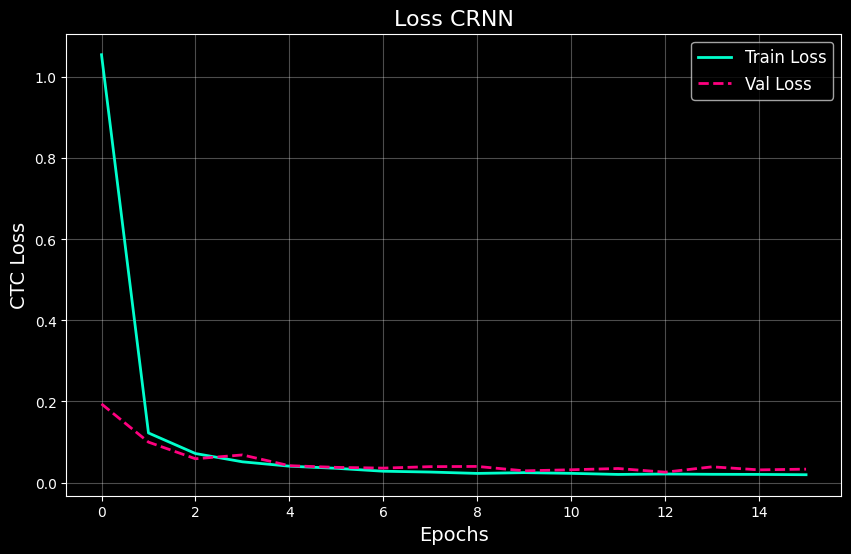

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss', color='#00ffcc', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', color='#ff007f', linewidth=2, linestyle='--')

plt.title('Loss CRNN', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('CTC Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.savefig('learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()
